In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
image = Image.open("cat.jpg").convert("L")
image_array = np.array(image)
height, width = image_array.shape
data = image_array.reshape(height, width)

In [ ]:
mean = np.mean(data, axis=0)
centred_data = data - mean


In [ ]:
cov_matrix = np.cov(centred_data, rowvar=False)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

d:\sem-6\AI-ML\workshop-1\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\sem-6\AI-ML\workshop-1\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


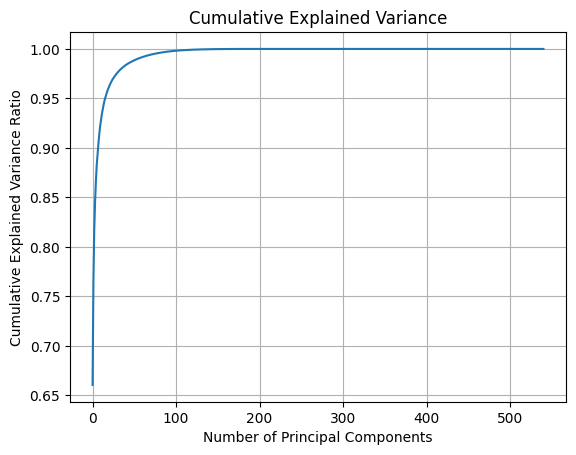

In [ ]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid()
plt.show()

In [ ]:
k = 50
components = eigenvectors[:, :k]

In [ ]:
compressed_data = np.dot(centred_data, components)
compressed_image = compressed_data.reshape(height, k)


In [ ]:
decompressed_data = np.dot(compressed_data, components.T) + mean
decompressed_image = decompressed_data.reshape(height, width)

TypeError: Image data of dtype complex128 cannot be converted to float

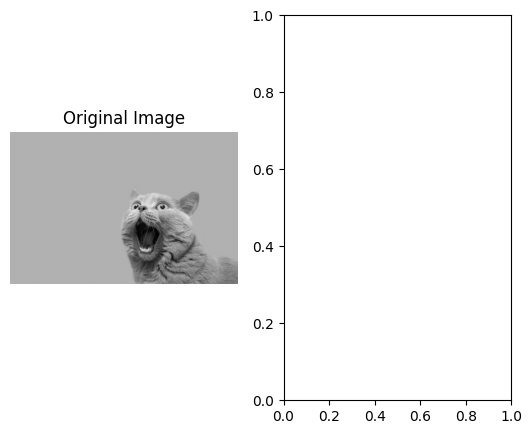

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(compressed_image, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(decompressed_image, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()